In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta


# Donnés

In [13]:
# 1. Créer des données avec un timestamp
dates = pd.date_range(start="2026-01-01", periods=9, freq="h")  # 10 points, toutes les heures
valeurs = np.random.randint(10, 100, size=9)

df = pd.DataFrame({
    "timestamp": dates,
    "valeur": valeurs
})
print(dates)
print(df)

DatetimeIndex(['2026-01-01 00:00:00', '2026-01-01 01:00:00',
               '2026-01-01 02:00:00', '2026-01-01 03:00:00',
               '2026-01-01 04:00:00', '2026-01-01 05:00:00',
               '2026-01-01 06:00:00', '2026-01-01 07:00:00',
               '2026-01-01 08:00:00'],
              dtype='datetime64[us]', freq='h')
            timestamp  valeur
0 2026-01-01 00:00:00      11
1 2026-01-01 01:00:00      30
2 2026-01-01 02:00:00      59
3 2026-01-01 03:00:00      51
4 2026-01-01 04:00:00      61
5 2026-01-01 05:00:00      58
6 2026-01-01 06:00:00      65
7 2026-01-01 07:00:00      24
8 2026-01-01 08:00:00      92


In [30]:
dates=[1,2,3,4,5,6,7,8,9,10]
values=[10,20,30,40,50,60,70,80,90,100]
df=pd.DataFrame({'dates':dates,'valeure':values})
print(df)

   dates  valeure
0      1       10
1      2       20
2      3       30
3      4       40
4      5       50
5      6       60
6      7       70
7      8       80
8      9       90
9     10      100


# Lire des Donnés a partire d'un fichié log

In [29]:
with open("machine_sensor.log", "r", encoding="utf-8") as f:
    for i, ligne in enumerate(f):
        print(ligne.strip())
        if i > 5:
            break


[2026-07-25 20:54:25] [INFO] Température normale : 59°C
[2026-07-25 20:54:26] [INFO] Température normale : 50°C
[2026-07-25 20:54:27] [ALERTE] Surchauffe détectée ! Température : 80°C
[2026-07-25 20:54:28] [INFO] Température normale : 55°C
[2026-07-25 20:54:29] [ALERTE] Surchauffe détectée ! Température : 73°C
[2026-07-25 20:54:30] [INFO] Température normale : 63°C
[2026-07-25 20:55:24] [INFO] Température normale : 52°C


# manipulatoin des donnés (csv) avec pandas 

In [37]:
import pandas as pd 
##################simple
# df = pd.read_csv("automatisme_donnees.csv", sep=";")
# Si le fichier a un encodage particulier (accents qui buggent par ex.)
# df = pd.read_csv("mon_fichier.csv", encoding="utf-8")

# # Si tu veux utiliser une colonne comme index
# df = pd.read_csv("mon_fichier.csv", index_col="id")
############une colonne de dates à convertir automatiquement

df = pd.read_csv("automatisme_donnees.csv", parse_dates=["timestamp"])

# print(df)
print(df.shape)      # ex: (150, 4)
# print(df.head())     # aperçu
print(df.dtypes) 
df.info()
df.describe()          # stats (moyenne, min, max...) sur les colonnes numériques
df["statut"].unique()  # valeurs uniques d'une colonne
df["statut"].value_counts()  # compte les occurrences

(200, 8)
timestamp            datetime64[us]
machine_id                      str
statut                          str
temperature_C               float64
pression_bar                float64
vitesse_rpm                 float64
conso_energie_kWh           float64
nb_cycles                     int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          200 non-null    datetime64[us]
 1   machine_id         200 non-null    str           
 2   statut             200 non-null    str           
 3   temperature_C      192 non-null    float64       
 4   pression_bar       200 non-null    float64       
 5   vitesse_rpm        200 non-null    float64       
 6   conso_energie_kWh  200 non-null    float64       
 7   nb_cycles          200 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1

statut
MARCHE         154
ARRET           28
ALARME          13
MAINTENANCE      5
Name: count, dtype: int64

# Filtrer des données

In [41]:
# df[df["statut"] == "ALARME"]
# df[df["temperature_C"] > 70]
# df[(df["machine_id"] == "Four_D") & (df["statut"] == "ARRET")]
df[df["temperature_C"].isna()]   # lignes avec valeur manquante

,timestamp,machine_id,statut,temperature_C,pression_bar,vitesse_rpm,conso_energie_kWh,nb_cycles
5,2026-01-01 06:25:00,Presse_B,ALARME,NaN,4.05,0.0,0.24,0
13,2026-01-01 07:05:00,Robot_C,ARRET,NaN,4.95,0.0,0.33,0
40,2026-01-01 09:20:00,Robot_C,MARCHE,NaN,4.38,1138.0,3.60,41
49,2026-01-01 10:05:00,Pompe_E,MARCHE,NaN,4.30,1110.0,3.58,26
100,2026-01-01 14:20:00,Robot_C,ARRET,NaN,3.96,0.0,0.26,0
102,2026-01-01 14:30:00,Convoyeur_A,MARCHE,NaN,4.00,1238.0,4.47,32
154,2026-01-01 18:50:00,Convoyeur_A,MARCHE,NaN,3.92,1295.0,3.74,8
172,2026-01-01 20:20:00,Four_D,MARCHE,NaN,5.46,952.0,3.00,28


# Gestion des valeurs manquantes 

In [65]:
# df.isna().sum()                          # nb de valeurs manquantes par colonne
#df["temperature_C"].fillna(df["temperature_C"].mean())   # remplacer par la moyenne
#df["temperature_C"].interpolate()        # interpolation (utile pour séries temporelles)
df.dropna(subset=["temperature_C"])      # supprimer les lignes concernées

,machine_id,statut,temperature_C,pression_bar,vitesse_rpm,conso_energie_kWh,nb_cycles,alerte_temp,hors_norme
timestamp,,,,,,,,,
2026-01-01 06:00:00,Four_D,MAINTENANCE,60.2,4.96,0.0,3.22,0,False,False
2026-01-01 06:05:00,Robot_C,MARCHE,53.1,3.76,1138.0,2.92,23,False,False
2026-01-01 06:10:00,Four_D,ALARME,56.3,4.93,0.0,0.45,0,False,False
2026-01-01 06:15:00,Pompe_E,MARCHE,61.5,3.44,1136.0,2.61,15,False,False
2026-01-01 06:20:00,Robot_C,MARCHE,54.8,4.38,1263.0,4.50,8,False,False
...,...,...,...,...,...,...,...,...,...
2026-01-01 22:15:00,Convoyeur_A,MARCHE,50.3,4.52,991.0,2.49,19,False,False
2026-01-01 22:20:00,Four_D,MARCHE,59.2,4.62,1383.0,4.96,43,False,False
2026-01-01 22:25:00,Four_D,ARRET,54.3,4.99,0.0,0.53,0,False,False


# Regroupement et agrégation (par machine, par statut...)

In [50]:
#df.groupby("machine_id")["temperature_C"].mean()
#df.groupby("machine_id")["conso_energie_kWh"].sum()
#df.groupby(["machine_id", "statut"]).size()   # combien de fois chaque combinaison
df.groupby("machine_id").agg({
    "temperature_C": "mean",
    "conso_energie_kWh": "sum",
    "nb_cycles": "sum"
})

,temperature_C,conso_energie_kWh,nb_cycles
machine_id,,,
Convoyeur_A,56.058333,133.23,938
Four_D,53.689744,104.82,594
Pompe_E,55.384091,136.97,884
Presse_B,54.702778,93.21,644
Robot_C,56.900000,104.59,787


# Manipulation des dates/timestamps 

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

df["2026-01-01"]                          # toutes les données de ce jour
df["2026-01-01 08:00":"2026-01-01 09:00"] # plage horaire précise

df.resample("1h").mean(numeric_only=True)  # moyenne par heure (très utilisé en industrie)
df.resample("1D").sum(numeric_only=True)   # total par jour

df.index.hour        # extraire l'heure
df.index.dayofweek   # jour de la semaine (utile pour repérer les patterns)

# Détection d'anomalies / seuils

In [59]:
df["alerte_temp"] = df["temperature_C"] > 65
df["hors_norme"] = (df["pression_bar"] < 3) | (df["pression_bar"] > 5)
seuil_depasse = df[df["alerte_temp"]]
print(seuil_depasse)

                      machine_id  statut  temperature_C  pression_bar  \
timestamp                                                               
2026-01-01 06:30:00       Four_D  MARCHE           69.8          4.61   
2026-01-01 09:25:00      Robot_C  MARCHE           67.5          4.26   
2026-01-01 09:30:00      Pompe_E  MARCHE           68.3          3.83   
2026-01-01 09:45:00      Pompe_E  MARCHE           72.0          4.72   
2026-01-01 10:30:00  Convoyeur_A  MARCHE           68.4          3.26   
2026-01-01 11:00:00      Pompe_E  MARCHE           69.2          4.51   
2026-01-01 11:10:00      Robot_C   ARRET           65.9          3.18   
2026-01-01 12:20:00     Presse_B  MARCHE           65.2          4.84   
2026-01-01 12:35:00      Robot_C  MARCHE           65.2          4.38   
2026-01-01 13:05:00  Convoyeur_A  MARCHE           70.7          4.10   
2026-01-01 13:15:00     Presse_B   ARRET           69.2          4.33   
2026-01-01 13:35:00     Presse_B  MARCHE           

# Tri

In [69]:
df.sort_values("temperature_C", ascending=False)
#df.sort_values(["machine_id", "timestamp"])
#print(df)

,machine_id,statut,temperature_C,pression_bar,vitesse_rpm,conso_energie_kWh,nb_cycles,alerte_temp,hors_norme
timestamp,,,,,,,,,
2026-01-01 18:40:00,Robot_C,MARCHE,74.6,3.89,1117.0,2.74,4,True,False
2026-01-01 13:35:00,Presse_B,MARCHE,72.4,4.94,1498.0,1.67,25,True,False
2026-01-01 09:45:00,Pompe_E,MARCHE,72.0,4.72,972.0,2.92,15,True,False
2026-01-01 13:05:00,Convoyeur_A,MARCHE,70.7,4.10,1016.0,3.55,47,True,False
2026-01-01 06:30:00,Four_D,MARCHE,69.8,4.61,1017.0,3.75,41,True,False
...,...,...,...,...,...,...,...,...,...
2026-01-01 10:05:00,Pompe_E,MARCHE,NaN,4.30,1110.0,3.58,26,False,False
2026-01-01 14:20:00,Robot_C,ARRET,NaN,3.96,0.0,0.26,0,False,False
2026-01-01 14:30:00,Convoyeur_A,MARCHE,NaN,4.00,1238.0,4.47,32,False,False


# Création de nouvelles colonnes calculées

In [70]:
df["temp_F"] = df["temperature_C"] * 9/5 + 32
df["conso_par_cycle"] = df["conso_energie_kWh"] / df["nb_cycles"].replace(0, pd.NA)

# Pivot table (tableau croisé — très pratique pour rapports)

In [71]:
pd.pivot_table(df, values="temperature_C", index="machine_id", columns="statut", aggfunc="mean")

statut,ALARME,ARRET,MAINTENANCE,MARCHE
machine_id,,,,
Convoyeur_A,NaN,58.300000,52.20,56.105882
Four_D,53.425000,54.310000,58.20,53.073913
Pompe_E,60.800000,44.833333,NaN,56.040000
Presse_B,49.300000,59.928571,49.05,54.543478
Robot_C,51.566667,58.120000,NaN,57.241379


# Export des résultats

In [73]:
df.to_csv("resultats_analyse.csv", index=False)
df.to_excel("rapport_machines.xlsx", index=False)

# Fusionner plusieurs source

In [77]:
df_final = pd.concat([df,df])              # empiler des fichiers similaires
# df_merged = pd.merge(df_mesures, df_infos_machine, on="machine_id")  # jointure
print(df_final)

                      machine_id       statut  temperature_C  pression_bar  \
timestamp                                                                    
2026-01-01 06:00:00       Four_D  MAINTENANCE           60.2          4.96   
2026-01-01 06:05:00      Robot_C       MARCHE           53.1          3.76   
2026-01-01 06:10:00       Four_D       ALARME           56.3          4.93   
2026-01-01 06:15:00      Pompe_E       MARCHE           61.5          3.44   
2026-01-01 06:20:00      Robot_C       MARCHE           54.8          4.38   
...                          ...          ...            ...           ...   
2026-01-01 22:15:00  Convoyeur_A       MARCHE           50.3          4.52   
2026-01-01 22:20:00       Four_D       MARCHE           59.2          4.62   
2026-01-01 22:25:00       Four_D        ARRET           54.3          4.99   
2026-01-01 22:30:00       Four_D       MARCHE           55.4          3.86   
2026-01-01 22:35:00  Convoyeur_A       MARCHE           62.3    

# Courbe temporelle

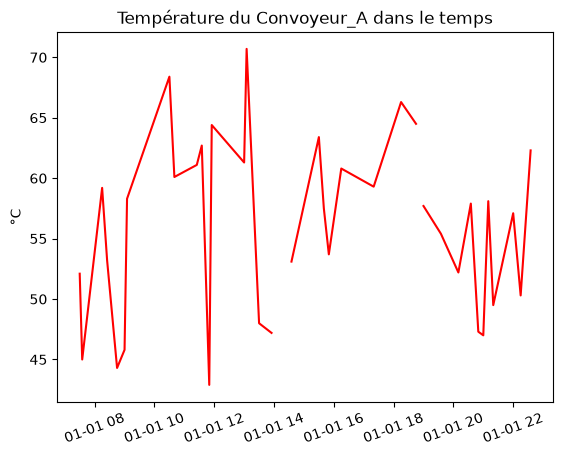

In [83]:
import matplotlib.pyplot as plt

df = pd.read_csv("automatisme_donnees.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

sub = df[df["machine_id"] == "Convoyeur_A"]
plt.plot(sub.index, sub["temperature_C"], color="red")
plt.title("Température du Convoyeur_A dans le temps")
plt.ylabel("°C")
plt.xticks(rotation=20)
plt.show()

# Histogramme / barres

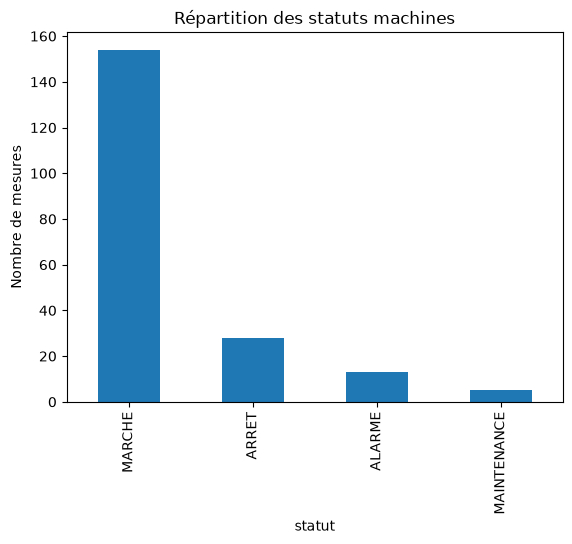

In [84]:
df["statut"].value_counts().plot(kind="bar")
plt.title("Répartition des statuts machines")
plt.ylabel("Nombre de mesures")
plt.show()

# Barres horizontales groupées

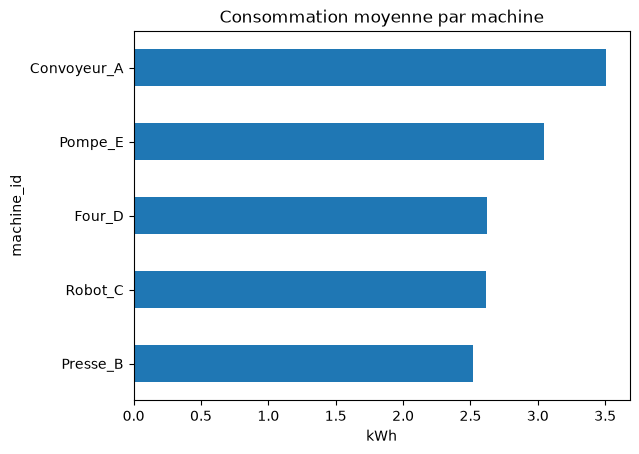

In [85]:
df.groupby("machine_id")["conso_energie_kWh"].mean().sort_values().plot(kind="barh")
plt.title("Consommation moyenne par machine")
plt.xlabel("kWh")
plt.show()

# Nuage de points (scatter)

In [ ]:
plt.scatter(df["temperature_C"], df["pression_bar"], alpha=0.5)
plt.title("Pression vs Température")
plt.xlabel("Température (°C)")
plt.ylabel("Pression (bar)")
plt.show()

 # mini tableau de bord de supervision 

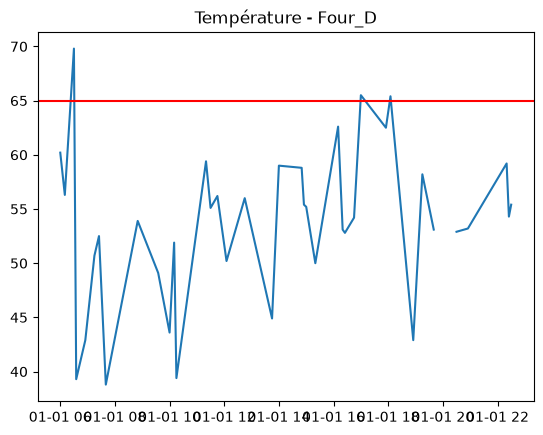

In [ ]:
# Lire les données
df = pd.read_csv("automatisme_donnees.csv", parse_dates=["timestamp"])

# Garder seulement une machine
sub = df[df["machine_id"] == "Four_D"]

# Tracer la température dans le temps
plt.plot(sub["timestamp"], sub["temperature_C"])
plt.axhline(65, color="red")  # ligne du seuil d'alarme
plt.title("Température - Four_D")
plt.show()

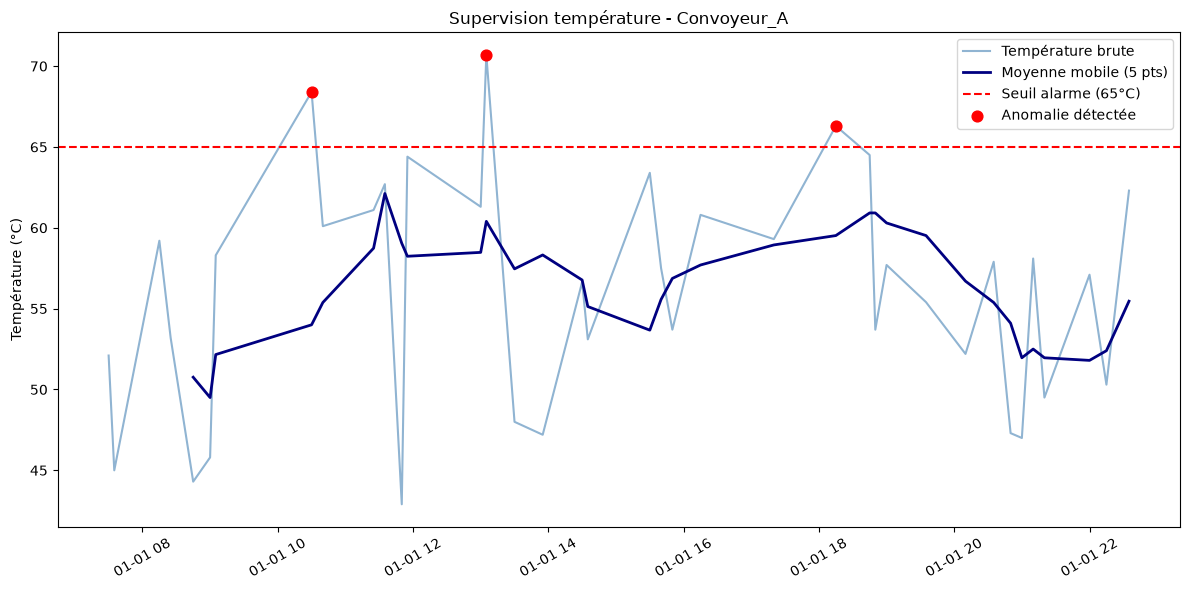

Nombre d'anomalies détectées : 3


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. LECTURE ET NETTOYAGE (pandas) ---
df = pd.read_csv("automatisme_donnees.csv", parse_dates=["timestamp"])
df["temperature_C"] = df["temperature_C"].interpolate()  # combler les trous capteur
df = df.set_index("timestamp")

sub = df[df["machine_id"] == "Convoyeur_A"].copy()

# --- 2. TRAITEMENT (pandas) ---
SEUIL_MAX = 65
sub["moyenne_mobile"] = sub["temperature_C"].rolling(window=5).mean()  # lisse le signal
sub["anomalie"] = sub["temperature_C"] > SEUIL_MAX                     # flag dépassement

# --- 3. VISUALISATION (matplotlib) ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(sub.index, sub["temperature_C"], label="Température brute", color="steelblue", alpha=0.6)
ax.plot(sub.index, sub["moyenne_mobile"], label="Moyenne mobile (5 pts)", color="navy", linewidth=2)
ax.axhline(SEUIL_MAX, color="red", linestyle="--", label=f"Seuil alarme ({SEUIL_MAX}°C)")

anomalies = sub[sub["anomalie"]]
ax.scatter(anomalies.index, anomalies["temperature_C"], color="red", zorder=5,
           label="Anomalie détectée", s=60)

ax.set_title("Supervision température - Convoyeur_A")
ax.set_ylabel("Température (°C)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("dashboard_supervision.png", dpi=150)
plt.show()

print(f"Nombre d'anomalies détectées : {sub['anomalie'].sum()}")